In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/bkash-presents-nsucec-datathon/public/sample_submission.csv
/kaggle/input/competitions/bkash-presents-nsucec-datathon/public/README.md
/kaggle/input/competitions/bkash-presents-nsucec-datathon/public/kyc.parquet
/kaggle/input/competitions/bkash-presents-nsucec-datathon/public/train_labels.csv
/kaggle/input/competitions/bkash-presents-nsucec-datathon/public/test.csv
/kaggle/input/competitions/bkash-presents-nsucec-datathon/public/dayend_balance/balance_2024-01.parquet
/kaggle/input/competitions/bkash-presents-nsucec-datathon/public/dayend_balance/balance_2024-03.parquet
/kaggle/input/competitions/bkash-presents-nsucec-datathon/public/dayend_balance/balance_2024-02.parquet
/kaggle/input/competitions/bkash-presents-nsucec-datathon/public/transactions/trx_2024-03.parquet
/kaggle/input/competitions/bkash-presents-nsucec-datathon/public/transactions/trx_2024-01.parquet
/kaggle/input/competitions/bkash-presents-nsucec-datathon/public/transactions/trx_2024-02.parquet

In [13]:
import os
from pyspark.sql import SparkSession
from pyspark.sql.functions import broadcast

# --- THE JVM FIX ---
os.environ["PYSPARK_SUBMIT_ARGS"] = "--driver-java-options '-Djava.security.manager=allow' pyspark-shell"

# --- 1. ENVIRONMENT FIXED PATH ---
# Kaggle-এর ইনপুট ফোল্ডারের রিয়েল পরম পাথ (Absolute Path) সরাসরি বসিয়ে দিলাম
BASE_PATH = "/kaggle/input/competitions/bkash-presents-nsucec-datathon/public/"

print(f"Forcing absolute data path to: {BASE_PATH}")

# --- 2. START SPARK (ন্যানোসেকেন্ড ও কনফিগ ফিক্স সহ) ---
spark = SparkSession.builder \
    .appName("FictiPay_Churn_Pipeline_Stage1") \
    .config("spark.driver.memory", "14g") \
    .config("spark.sql.legacy.parquet.nanosAsLong", "true") \
    .config("spark.sql.parquet.outputTimestampType", "TIMESTAMP_MICROS") \
    .getOrCreate()

print("Spark Session configuration forced successfully!")

# --- 3. LOAD THE DATA ---
kyc_df = spark.read.parquet(f"{BASE_PATH}kyc.parquet")
labels_df = spark.read.csv(f"{BASE_PATH}train_labels.csv", header=True, inferSchema=True)
transactions_df = spark.read.parquet(f"{BASE_PATH}transactions/")
balances_df = spark.read.parquet(f"{BASE_PATH}dayend_balance/")

# --- 4. CREATE ANCHOR TABLE & SAMPLE ---
master_kyc_df = kyc_df.join(labels_df, on="ACCOUNT_ID", how="inner")
sampled_kyc_df = master_kyc_df.sampleBy("Churn", fractions={0: 0.1, 1: 0.1}, seed=42)
sampled_user_ids = sampled_kyc_df.select("ACCOUNT_ID")

# Broadcast join & dropping duplicates
sampled_transactions_df = transactions_df.join(
    broadcast(sampled_user_ids), 
    transactions_df.SRC_ACCOUNT == sampled_user_ids.ACCOUNT_ID, \
    "inner"
).drop(sampled_user_ids.ACCOUNT_ID)

sampled_balances_df = balances_df.join(
    broadcast(sampled_user_ids),
    "ACCOUNT_ID",
    "inner"
)

# --- 5. CACHE AND MATERIALIZE ---
sampled_transactions_df.cache()
sampled_balances_df.cache()

# ফোর্স অ্যাকশন
print(f"Sampled Transactions Count: {sampled_transactions_df.count()}")
print(f"Sampled Balances Count: {sampled_balances_df.count()}")
print("Boom! Data Loaded, Sampled, & Cached! Ready for Feature Engineering.")

Forcing absolute data path to: /kaggle/input/competitions/bkash-presents-nsucec-datathon/public/
Spark Session configuration forced successfully!


Sampled Transactions Count: 5099024


Sampled Balances Count: 5409859
Boom! Data Loaded, Sampled, & Cached! Ready for Feature Engineering.


In [14]:
print("--- Transactions Data ---")
sampled_transactions_df.show(5, truncate=False)

print("--- Balances Data ---")
sampled_balances_df.show(5, truncate=False)

--- Transactions Data ---
+------------------+-------------------+------------+------------+--------+-------+
|TrxID             |TRX_DATETIME       |SRC_ACCOUNT |DST_ACCOUNT |TRX_TYPE|TRX_AMT|
+------------------+-------------------+------------+------------+--------+-------+
|TRX000000000006139|2024-03-04 14:04:30|CUST00000035|BILL00012205|BillPay |230.0  |
|TRX000000000006140|2024-03-07 14:22:13|CUST00000035|CUST00000035|CashIn  |70.06  |
|TRX000000000006141|2024-03-08 13:44:03|CUST00000035|CUST00000035|CashIn  |82.5   |
|TRX000000000006142|2024-03-10 18:05:24|CUST00000035|CUST00000035|CashIn  |6594.15|
|TRX000000000006143|2024-03-20 11:44:14|CUST00000035|CUST00000035|CashOut |66.14  |
+------------------+-------------------+------------+------------+--------+-------+
only showing top 5 rows
--- Balances Data ---
+------------+----------+-----------------+
|ACCOUNT_ID  |DATE      |AVAILABLE_BALANCE|
+------------+----------+-----------------+
|CUST00000035|2024-01-01|5141.2         

In [15]:
import pyspark.sql.functions as F

print("Starting Feature Engineering...")

# --- 1. AGGREGATE TRANSACTIONS ---
# Group by SRC_ACCOUNT (the sender) to build our core metrics
tx_core_features = sampled_transactions_df.groupBy("SRC_ACCOUNT").agg(
    F.count("TrxID").alias("total_tx_count"),
    F.sum("TRX_AMT").alias("total_spend_amt"),
    F.avg("TRX_AMT").alias("avg_tx_amt"),
    F.max("TRX_DATETIME").alias("last_tx_date")
).withColumnRenamed("SRC_ACCOUNT", "ACCOUNT_ID") # Rename for easy joining later

# Pivot to get behavior by transaction type (P2P, Merchant, Bill)
tx_type_features = sampled_transactions_df.groupBy("SRC_ACCOUNT") \
    .pivot("TRX_TYPE") \
    .count() \
    .fillna(0) \
    .withColumnRenamed("SRC_ACCOUNT", "ACCOUNT_ID")

# --- 2. AGGREGATE BALANCES ---
balance_features = sampled_balances_df.groupBy("ACCOUNT_ID").agg(
    F.avg("AVAILABLE_BALANCE").alias("avg_daily_balance"),
    F.stddev("AVAILABLE_BALANCE").alias("balance_volatility"),
    F.min("AVAILABLE_BALANCE").alias("min_balance"),
    F.max("AVAILABLE_BALANCE").alias("max_balance")
)

# --- 3. JOIN IT ALL TOGETHER (The Customer 360 View) ---
# We start with our sampled_kyc_df anchor and left join the features
customer_360_df = sampled_kyc_df \
    .join(tx_core_features, on="ACCOUNT_ID", how="left") \
    .join(tx_type_features, on="ACCOUNT_ID", how="left") \
    .join(balance_features, on="ACCOUNT_ID", how="left")

# Fill nulls for users who might have KYC records but zero transactions/balances
customer_360_df = customer_360_df.fillna(0, subset=["total_tx_count", "total_spend_amt", "avg_tx_amt"])

print("Feature Engineering Complete! Customer 360 Table Created.")
customer_360_df.show(5)

Starting Feature Engineering...


Feature Engineering Complete! Customer 360 Table Created.


+------------+------------+-------------------+------+----------+-----+--------------+------------------+------------------+-------------------+-------+------+-------+-----------+---+------------------+------------------+-----------+-----------+
|  ACCOUNT_ID|ACCOUNT_TYPE|  ACCOUNT_OPEN_DATE|GENDER|    REGION|CHURN|total_tx_count|   total_spend_amt|        avg_tx_amt|       last_tx_date|BillPay|CashIn|CashOut|MerchantPay|P2P| avg_daily_balance|balance_volatility|min_balance|max_balance|
+------------+------------+-------------------+------+----------+-----+--------------+------------------+------------------+-------------------+-------+------+-------+-----------+---+------------------+------------------+-----------+-----------+
|CUST00074345|    Customer|1616803200000000000|  Male|Chattogram|    0|             8| 95806.84000000001|11975.855000000001|2024-03-30 11:01:41|      3|     1|      0|          3|  1| 437.7816483516483|  822.901481531813|        0.0|    2891.69|
|CUST00094072|  

In [16]:
import pyspark.sql.functions as F

print("Starting Advanced Feature Engineering...")

# --- 1. ESTABLISH THE REFERENCE DATE ("TODAY") ---
# Find the absolute latest transaction date in the dataset to act as our cutoff point
max_date_row = sampled_transactions_df.select(F.max("TRX_DATETIME")).collect()[0][0]
ref_date = F.lit(max_date_row)

print(f"Dataset Reference Date established as: {max_date_row}")

# Add a 'days_ago' column to both datasets to make windowing easier
tx_df = sampled_transactions_df.withColumn("days_ago", F.datediff(ref_date, F.col("TRX_DATETIME")))
bal_df = sampled_balances_df.withColumn("days_ago", F.datediff(ref_date, F.col("DATE")))


# --- 2. TRANSACTION FEATURES (Recency, Frequency, Monetary, Behavioral) ---
tx_features = tx_df.groupBy("SRC_ACCOUNT").agg(
    # Recency
    F.min("days_ago").alias("days_since_last_txn"),
    
    # Frequency (30 & 90 days)
    F.count(F.when(F.col("days_ago") <= 30, True)).alias("txn_count_30d"),
    F.count(F.when(F.col("days_ago") <= 90, True)).alias("txn_count_90d"),
    
    # Monetary & Volatility
    F.avg(F.when(F.col("days_ago") <= 30, F.col("TRX_AMT"))).alias("avg_txn_amt_30d"),
    F.stddev(F.when(F.col("days_ago") <= 90, F.col("TRX_AMT"))).alias("stddev_txn_amt_90d"),
    
    # Base counts for Ratios (Hidden in final output)
    F.count("TrxID").alias("_total_txns"),
    F.count(F.when(F.col("TRX_TYPE") == "P2P", True)).alias("_p2p_txns"),
    F.count(F.when(F.col("TRX_TYPE") == "Bill", True)).alias("_bill_txns")
)

# Calculate Behavioral Ratios and drop the temporary count columns
tx_features = tx_features.withColumn(
    "ratio_p2p_to_total", F.col("_p2p_txns") / F.col("_total_txns")
).withColumn(
    "ratio_billpay_to_total", F.col("_bill_txns") / F.col("_total_txns")
).drop("_total_txns", "_p2p_txns", "_bill_txns") \
 .withColumnRenamed("SRC_ACCOUNT", "ACCOUNT_ID") # Rename for the master join


# --- 3. BALANCE FEATURES (Health & Temporal Trends) ---
bal_features = bal_df.groupBy("ACCOUNT_ID").agg(
    F.avg(F.when(F.col("days_ago") <= 30, F.col("AVAILABLE_BALANCE"))).alias("avg_daily_balance_30d"),
    F.avg(F.when(F.col("days_ago") <= 90, F.col("AVAILABLE_BALANCE"))).alias("_avg_daily_balance_90d"), # Temp column
    F.stddev(F.when(F.col("days_ago") <= 90, F.col("AVAILABLE_BALANCE"))).alias("balance_volatility_90d")
)

# Calculate the Balance Trend Ratio (30d avg / 90d avg)
# We use 'when' to prevent Divide-By-Zero errors if the 90d avg happens to be exactly 0
bal_features = bal_features.withColumn(
    "balance_trend_ratio", 
    F.col("avg_daily_balance_30d") / F.when(F.col("_avg_daily_balance_90d") == 0, 1).otherwise(F.col("_avg_daily_balance_90d"))
).drop("_avg_daily_balance_90d")


# --- 4. KYC FEATURES (Tenure) ---
# --- 4. KYC FEATURES (Tenure) ---
# Convert the BIGINT (nanoseconds) into a proper Date object
kyc_features = sampled_kyc_df.withColumn(
    "ACCOUNT_OPEN_DATE_CLEAN", 
    F.to_date(F.to_timestamp(F.col("ACCOUNT_OPEN_DATE") / 1e9))
)

# Now safely calculate the datediff
kyc_features = kyc_features.withColumn(
    "account_tenure_days", 
    F.datediff(ref_date, F.col("ACCOUNT_OPEN_DATE_CLEAN"))
).drop("ACCOUNT_OPEN_DATE_CLEAN") # Drop the temporary column


# --- 5. THE MASTER JOIN (Building the Customer 360) ---
customer_360_df = kyc_features \
    .join(tx_features, on="ACCOUNT_ID", how="left") \
    .join(bal_features, on="ACCOUNT_ID", how="left")

# Clean up Nulls: 
# Users with NO transactions in the last 30 days will have 'null' for counts/sums. 
# We must fill these with 0 so the Machine Learning model doesn't crash.
fill_zero_cols = [
    "txn_count_30d", "txn_count_90d", "avg_txn_amt_30d", "stddev_txn_amt_90d", 
    "ratio_p2p_to_total", "ratio_billpay_to_total", "balance_trend_ratio"
]
customer_360_df = customer_360_df.fillna(0, subset=fill_zero_cols)

# We fill recency nulls with a very large number (e.g., 9999) because '0' would imply they transacted today.
customer_360_df = customer_360_df.fillna(9999, subset=["days_since_last_txn"])

print("Advanced Feature Engineering Complete! Final Schema:")
customer_360_df.printSchema()

Starting Advanced Feature Engineering...


Dataset Reference Date established as: 2024-03-31 22:59:40
Advanced Feature Engineering Complete! Final Schema:
root
 |-- ACCOUNT_ID: string (nullable = true)
 |-- ACCOUNT_TYPE: string (nullable = true)
 |-- ACCOUNT_OPEN_DATE: long (nullable = true)
 |-- GENDER: string (nullable = true)
 |-- REGION: string (nullable = true)
 |-- CHURN: integer (nullable = true)
 |-- account_tenure_days: integer (nullable = true)
 |-- days_since_last_txn: integer (nullable = true)
 |-- txn_count_30d: long (nullable = true)
 |-- txn_count_90d: long (nullable = true)
 |-- avg_txn_amt_30d: double (nullable = false)
 |-- stddev_txn_amt_90d: double (nullable = false)
 |-- ratio_p2p_to_total: double (nullable = false)
 |-- ratio_billpay_to_total: double (nullable = false)
 |-- avg_daily_balance_30d: double (nullable = true)
 |-- balance_volatility_90d: double (nullable = true)
 |-- balance_trend_ratio: double (nullable = false)



In [17]:
import pandas as pd
import numpy as np
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, precision_score, recall_score

print("--- Step 1: Converting Spark DataFrame to Pandas ---")

df_ml = customer_360_df.toPandas()
print(f"Data successfully converted! Shape: {df_ml.shape}")

# --- Step 2: Feature & Target Preparation ---
print("\n--- Step 2: Preparing Features and Target ---")


df_ml = df_ml.set_index('ACCOUNT_ID')


y = df_ml['CHURN']


drop_cols = ['ACCOUNT_TYPE', 'ACCOUNT_OPEN_DATE', 'CHURN']
X = df_ml.drop(columns=drop_cols)


categorical_cols = ['GENDER', 'REGION']
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)


X_encoded = X_encoded.fillna(0)

print(f"Final Features Ready. Total features after encoding: {X_encoded.shape[1]}")

# --- Step 3: Stratified Train-Test Split ---

X_train, X_val, y_train, y_val = train_test_split(
    X_encoded, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train Size: {X_train.shape}, Validation Size: {X_val.shape}")

# --- Step 4: Class Imbalance Handling ---

ratio_neg_to_pos = (len(y_train) - sum(y_train)) / sum(y_train)
print(f"Calculated scale_pos_weight: {ratio_neg_to_pos:.2f}")

# --- Step 5: LightGBM Model Training ---
print("\n--- Step 5: Training LightGBM Model ---")
lgb_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    num_leaves=31,
    scale_pos_weight=ratio_neg_to_pos,
    random_state=42,
    n_jobs=-1
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[]
)
print("Model Training Complete!")

# --- Step 6: Evaluation Metrics ---
print("\n--- Step 6: Model Performance Metrics ---")


val_probs = lgb_model.predict_proba(X_val)[:, 1]


def evaluate_top_k(y_true, y_prob, k=0.10):
    thresh = np.quantile(y_prob, 1 - k)
    y_pred_k = (y_prob >= thresh).astype(int)
    
    prec = precision_score(y_true, y_pred_k)
    rec = recall_score(y_true, y_pred_k)
    return prec, rec


auc_score = roc_auc_score(y_val, val_probs)
prec_at_10, rec_at_10 = evaluate_top_k(y_val, val_probs, k=0.10)

print("="*50)
print(f"Validation AUC-ROC Score : {auc_score:.4f}")
print(f"Precision @ Top 10% Risk : {prec_at_10:.4f}")
print(f"Recall @ Top 10% Risk    : {rec_at_10:.4f}")
print("="*50)

# --- Step 7: Feature Importance ---
print("\nTop 5 Most Important Features in Model:")
importances = pd.Series(lgb_model.feature_importances_, index=X_encoded.columns)
print(importances.sort_values(ascending=False).head(5))

--- Step 1: Converting Spark DataFrame to Pandas ---


Data successfully converted! Shape: (59449, 17)

--- Step 2: Preparing Features and Target ---
Final Features Ready. Total features after encoding: 20
Train Size: (47559, 20), Validation Size: (11890, 20)
Calculated scale_pos_weight: 6.81

--- Step 5: Training LightGBM Model ---
[LightGBM] [Info] Number of positive: 6091, number of negative: 41468
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.026305 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2266
[LightGBM] [Info] Number of data points in the train set: 47559, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.128072 -> initscore=-1.918110
[LightGBM] [Info] Start training from score -1.918110
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[L

In [19]:
import os
import pyspark.sql.functions as F
from pyspark.sql.functions import broadcast
import pandas as pd
import numpy as np

print("--- Step 1: Loading and Preparing Full Test Features in Spark ---")


test_df = spark.read.csv(f"{BASE_PATH}test.csv", header=True, inferSchema=True)
test_user_ids = test_df.select("ACCOUNT_ID")

print(f"Total rows in Test Set: {test_user_ids.count()}")


print("Building Features for Test Set...")


test_kyc_features = kyc_df.join(test_user_ids, on="ACCOUNT_ID", how="inner") \
    .withColumn("ACCOUNT_OPEN_DATE_CLEAN", F.to_date(F.to_timestamp(F.col("ACCOUNT_OPEN_DATE") / 1e9))) \
    .withColumn("account_tenure_days", F.datediff(ref_date, F.col("ACCOUNT_OPEN_DATE_CLEAN"))) \
    .drop("ACCOUNT_OPEN_DATE_CLEAN")


test_tx_df = transactions_df.join(broadcast(test_user_ids), transactions_df.SRC_ACCOUNT == test_user_ids.ACCOUNT_ID, "inner") \
    .withColumn("days_ago", F.datediff(ref_date, F.col("TRX_DATETIME")))

test_tx_features = test_tx_df.groupBy("SRC_ACCOUNT").agg(
    F.min("days_ago").alias("days_since_last_txn"),
    F.count(F.when(F.col("days_ago") <= 30, True)).alias("txn_count_30d"),
    F.count(F.when(F.col("days_ago") <= 90, True)).alias("txn_count_90d"),
    F.avg(F.when(F.col("days_ago") <= 30, F.col("TRX_AMT"))).alias("avg_txn_amt_30d"),
    F.stddev(F.when(F.col("days_ago") <= 90, F.col("TRX_AMT"))).alias("stddev_txn_amt_90d"),
    F.count("TrxID").alias("_total_txns"),
    F.count(F.when(F.col("TRX_TYPE") == "P2P", True)).alias("_p2p_txns"),
    F.count(F.when(F.col("TRX_TYPE") == "Bill", True)).alias("_bill_txns")
).withColumn("ratio_p2p_to_total", F.col("_p2p_txns") / F.col("_total_txns")) \
 .withColumn("ratio_billpay_to_total", F.col("_bill_txns") / F.col("_total_txns")) \
 .drop("_total_txns", "_p2p_txns", "_bill_txns") \
 .withColumnRenamed("SRC_ACCOUNT", "ACCOUNT_ID")


test_bal_df = balances_df.join(broadcast(test_user_ids), "ACCOUNT_ID", "inner") \
    .withColumn("days_ago", F.datediff(ref_date, F.col("DATE")))

test_bal_features = test_bal_df.groupBy("ACCOUNT_ID").agg(
    F.avg(F.when(F.col("days_ago") <= 30, F.col("AVAILABLE_BALANCE"))).alias("avg_daily_balance_30d"),
    F.avg(F.when(F.col("days_ago") <= 90, F.col("AVAILABLE_BALANCE"))).alias("_avg_daily_balance_90d"),
    F.stddev(F.when(F.col("days_ago") <= 90, F.col("AVAILABLE_BALANCE"))).alias("balance_volatility_90d")
).withColumn("balance_trend_ratio", F.col("avg_daily_balance_30d") / F.when(F.col("_avg_daily_balance_90d") == 0, 1).otherwise(F.col("_avg_daily_balance_90d"))) \
 .drop("_avg_daily_balance_90d")


test_customer_360 = test_kyc_features \
    .join(test_tx_features, on="ACCOUNT_ID", how="left") \
    .join(test_bal_features, on="ACCOUNT_ID", how="left")


fill_zero_cols = [
    "txn_count_30d", "txn_count_90d", "avg_txn_amt_30d", "stddev_txn_amt_90d", 
    "ratio_p2p_to_total", "ratio_billpay_to_total", "balance_trend_ratio"
]
test_customer_360 = test_customer_360.fillna(0, subset=fill_zero_cols)
test_customer_360 = test_customer_360.fillna(9999, subset=["days_since_last_txn"])

# --- Step 2: Converting Test Data to Pandas ---
print("\n--- Step 2: Converting Test Features to Pandas ---")
df_test_ml = test_customer_360.toPandas()


df_test_ml = df_test_ml.set_index('ACCOUNT_ID')


X_test_final = df_test_ml.drop(columns=['ACCOUNT_TYPE', 'ACCOUNT_OPEN_DATE'], errors='ignore')
X_test_final = pd.get_dummies(X_test_final, columns=['GENDER', 'REGION'], drop_first=True)
X_test_final = X_test_final.fillna(0)


X_test_final = X_test_final.reindex(columns=X_train.columns, fill_value=0)

print(f"Test features aligned perfectly! Shape: {X_test_final.shape}")

# --- Step 3: Generating Predictions & Submission CSV ---
print("\n--- Step 3: Generating Final Churn Probabilities ---")


test_predictions = lgb_model.predict_proba(X_test_final)[:, 1]


submission_df = pd.DataFrame({
    'ACCOUNT_ID': X_test_final.index,
    'CHURN': test_predictions
})


submission_path = "submission.csv"
submission_df.to_csv(submission_path, index=False)

print(f"\n🎉 SUCCESS! Your final submission file is ready at: {submission_path}")
print("Submission Preview:")
print(submission_df.head(5))

--- Step 1: Loading and Preparing Full Test Features in Spark ---
Total rows in Test Set: 255000
Building Features for Test Set...

--- Step 2: Converting Test Features to Pandas ---


Test features aligned perfectly! Shape: (255000, 20)

--- Step 3: Generating Final Churn Probabilities ---

🎉 SUCCESS! Your final submission file is ready at: submission.csv
Submission Preview:
     ACCOUNT_ID     CHURN
0  CUST00000025  0.007650
1  CUST00000042  0.000038
2  CUST00000067  0.010984
3  CUST00000132  0.992737
4  CUST00000134  0.951442


In [20]:

print("--- Submission Sanity Check ---")
print(submission_df['CHURN'].describe())


high_risk_pct = (submission_df['CHURN'] > 0.5).mean() * 100
print(f"\nPercentage of High-Risk Churn Customers: {high_risk_pct:.2f}%")

--- Submission Sanity Check ---
count    255000.000000
mean          0.182892
std           0.339135
min           0.000002
25%           0.000066
50%           0.003757
75%           0.066100
max           0.999920
Name: CHURN, dtype: float64

Percentage of High-Risk Churn Customers: 19.46%


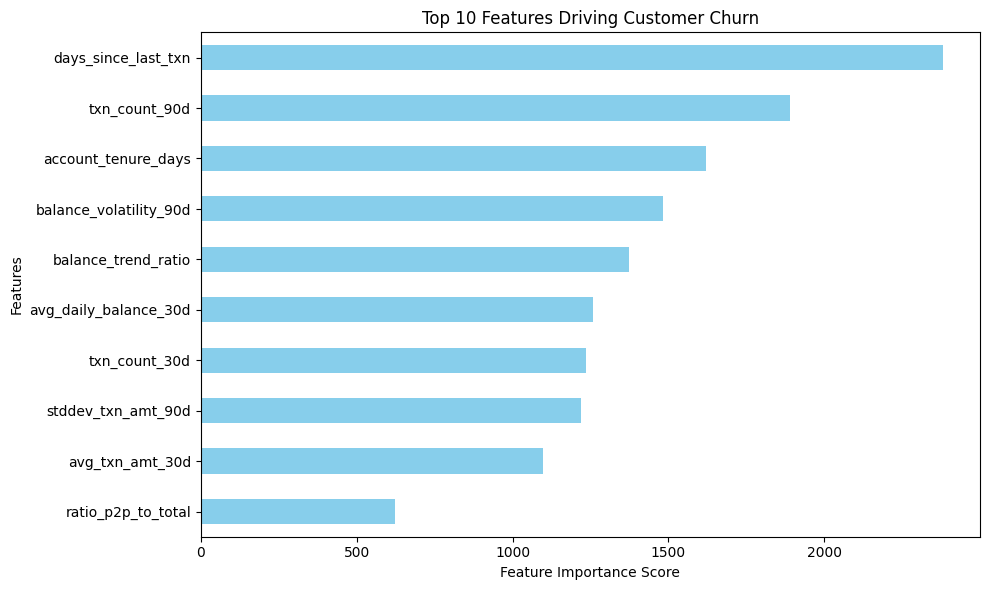

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

importances.sort_values(ascending=False).head(10).plot(kind='barh', color='skyblue')
plt.gca().invert_yaxis()
plt.title("Top 10 Features Driving Customer Churn")
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [ ]:
# BAsed on the features 